In [ ]:
# Install if needed (run once)
# !pip install torch gymnasium numpy matplotlib --quiet

# Core imports
import numpy as np                              # arrays
import torch                                    # neural net framework
import torch.nn as nn                           # layers
import torch.optim as optim                     # optimizers
import gymnasium as gym                         # RL environments
import random                                   # ε-greedy randomness
from collections import deque                   # for the replay buffer
import matplotlib.pyplot as plt                 # plotting
import warnings; warnings.filterwarnings("ignore")  # cleaner output

# Reproducibility
SEED = 42                                       # global seed
np.random.seed(SEED)                            # numpy
torch.manual_seed(SEED)                         # PyTorch
random.seed(SEED)                               # Python's RNG
print("Setup complete ✓")                       # confirmation


Setup complete ✓


The Environment — CartPole-v1
A pole is hinged on a cart that moves left or right. The agent's job is to keep the pole balanced as long as possible.

State (4 numbers): cart position, cart velocity, pole angle, pole angular velocity.
Actions (2): 0 = push left, 1 = push right.
Reward: +1 for every step the pole stays up (max 500 per episode).
Solved: average reward ≥ 195 over 100 episodes.
Recall from the slides: tabular Q-learning fails here because the state space is continuous — uncountably many possible (position, velocity, angle, angular-velocity) tuples.

In [ ]:
# Create the CartPole environment
env = gym.make("CartPole-v1")                   # standard Gymnasium env
state_dim = env.observation_space.shape[0]      # 4 features
n_actions = env.action_space.n                  # 2 actions

print(f"State dim:  {state_dim}")               # 4
print(f"# actions:  {n_actions}")               # 2

# Reset and show a sample state
state, _ = env.reset(seed=SEED)                 # initial state, deterministic
print(f"Sample state: {state}")                 # [pos, vel, angle, ang-vel]
print(f"State type:   {type(state)}, dtype={state.dtype}")  # numpy float32

State dim:  4
# actions:  2
Sample state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
State type:   <class 'numpy.ndarray'>, dtype=float32


2. Random Baseline — How Bad Is Random?

In [ ]:
def run_episodes(env, policy_fn, n_episodes=20):
    """Run policy_fn for n_episodes and return total reward per episode."""
    rewards = []                                 # one number per episode
    for _ in range(n_episodes):                  # one episode at a time
        state, _ = env.reset()                   # fresh start
        total = 0                                # running reward
        done = False                             # episode flag
        while not done:                          # step until done
            action = policy_fn(state)            # call the policy
            state, r, term, trunc, _ = env.step(action)  # take action
            total += r                           # accumulate reward
            done = term or trunc                 # check for end
        rewards.append(total)                    # log this episode's reward
    return rewards                               # list of per-episode rewards

# Random policy: ignore state, sample uniformly
random_policy = lambda s: env.action_space.sample()  # random action

# Evaluate
random_rewards = run_episodes(env, random_policy, n_episodes=20)
print(f"Random policy — mean reward: {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print(f"(CartPole's max possible is 500)")     # context

Random policy — mean reward: 21.1 ± 10.9
(CartPole's max possible is 500)


3. The Q-Network — Function Approximation

In [ ]:
class QNetwork(nn.Module):
    """Small MLP: state (4) → hidden (128) → hidden (128) → Q-values (n_actions)."""
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()                       # init base nn.Module
        self.net = nn.Sequential(                # convenient stack of layers
            nn.Linear(state_dim, hidden),        # in → hidden
            nn.ReLU(),                           # non-linearity
            nn.Linear(hidden, hidden),           # hidden → hidden
            nn.ReLU(),                           # non-linearity
            nn.Linear(hidden, n_actions)         # hidden → Q-value per action
        )

    def forward(self, x):
        """Forward pass: x → Q-values for every action."""
        return self.net(x)                       # shape: (batch, n_actions)

# Quick test of shapes
q_net = QNetwork(state_dim, n_actions)           # instantiate the network
dummy = torch.zeros(1, state_dim)                # one fake state
out = q_net(dummy)                               # forward pass
print(f"Q-net output shape: {out.shape}  (expect [1, {n_actions}])")  # confirm shape

Q-net output shape: torch.Size([1, 2])  (expect [1, 2])


4. Experience Replay — Break the Correlation

In [ ]:
class ReplayBuffer:
    """Fixed-size circular buffer of transitions."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)     # auto-drops oldest when full

    def push(self, state, action, reward, next_state, done):
        """Add one transition (s, a, r, s', done) to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Sample a random minibatch of transitions and return as tensors."""
        batch = random.sample(self.buffer, batch_size)         # uniform sampling
        states, actions, rewards, next_states, dones = zip(*batch)  # unpack

        # Convert each list to a tensor of the right type
        return (
            torch.FloatTensor(np.array(states)),               # (B, state_dim)
            torch.LongTensor(actions),                          # (B,)
            torch.FloatTensor(rewards),                         # (B,)
            torch.FloatTensor(np.array(next_states)),           # (B, state_dim)
            torch.FloatTensor(dones)                            # (B,) — 1 if terminal
        )

    def __len__(self):
        return len(self.buffer)                  # current size

# Quick sanity test
buf = ReplayBuffer(capacity=100)                 # small test buffer
buf.push(np.zeros(4), 0, 1.0, np.zeros(4), False)  # push one transition
print(f"Buffer size after 1 push: {len(buf)}")  # should print 1


Buffer size after 1 push: 1


5. The DQN Agent
This brings everything together:

Online network Q(·; θ) — updated every step
Target network Q(·; θ⁻) — a slowly-updated copy used for the Bellman target (slides: "stops the target chasing the prediction")
ε-greedy action selection for exploration
The loss minimized is the squared TD error:

In [ ]:
class DQNAgent:
    """Vanilla DQN with experience replay and a target network."""
    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99,
                 buffer_size=10000, batch_size=64, target_update=50):
        # Two networks: online (updated every step) and target (synced periodically)
        self.online = QNetwork(state_dim, n_actions)            # learns
        self.target = QNetwork(state_dim, n_actions)            # gives stable targets
        self.target.load_state_dict(self.online.state_dict())   # initial sync
        self.target.eval()                                       # target never trains directly

        # Optimizer for the online network only
        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()                              # squared TD error
        self.buffer = ReplayBuffer(buffer_size)                  # experience replay
        self.n_actions = n_actions                               # cache action count
        self.gamma = gamma                                       # discount factor
        self.batch_size = batch_size                             # minibatch size for updates
        self.target_update = target_update                       # sync target every N steps
        self.step_count = 0                                      # counter for syncing

    def act(self, state, epsilon):
        """ε-greedy action selection."""
        if random.random() < epsilon:                            # explore
            return random.randint(0, self.n_actions - 1)         # uniformly random action
        # Exploit: pick argmax_a Q(s, a)
        with torch.no_grad():                                    # no gradient needed for inference
            state_t = torch.FloatTensor(state).unsqueeze(0)      # add batch dim → (1, state_dim)
            q_values = self.online(state_t)                      # forward pass
            return int(q_values.argmax(dim=1).item())            # best action

    def update(self):
        """One gradient step on a random minibatch from the buffer."""
        # Don't start learning until the buffer has enough samples
        if len(self.buffer) < self.batch_size:                   # not enough data yet
            return None                                          # skip

        # Sample a random minibatch
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Current Q(s, a) for the actions we actually took
        q_values = self.online(states)                           # shape (B, n_actions)
        q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)  # pick action taken → (B,)

        # Bellman TARGET using the TARGET network (this is the key stability trick)
        with torch.no_grad():                                    # don't backprop through target
            next_q = self.target(next_states).max(dim=1)[0]      # max_a' Q(s', a'; θ⁻)
            # If next state is terminal, no future reward
            td_target = rewards + self.gamma * next_q * (1 - dones)

        # Compute MSE loss between prediction and target
        loss = self.loss_fn(q_values, td_target)                 # squared TD error

        # Standard PyTorch update sequence
        self.optimizer.zero_grad()                               # clear old grads
        loss.backward()                                          # backprop
        # Optional: clip gradients to prevent occasional huge updates
        torch.nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=1.0)
        self.optimizer.step()                                    # apply update

        # Periodically copy online weights into the target network
        self.step_count += 1                                     # tick step counter
        if self.step_count % self.target_update == 0:            # time to sync?
            self.target.load_state_dict(self.online.state_dict())  # hard update

        return loss.item()                                       # return loss for logging

6. The Training Loop
For every episode:

Reset env, accumulate reward step by step
Use ε-greedy to pick an action
Store the transition in the replay buffer
Do one gradient update on a random minibatch
Decay ε so we explore less over time

In [ ]:
def train_dqn(env, n_episodes=300,
              eps_start=1.0, eps_end=0.05, eps_decay=0.995):
    """Train a DQN agent on the given env. Returns reward log."""
    agent = DQNAgent(state_dim, n_actions)                       # fresh agent
    epsilon = eps_start                                           # initial exploration rate
    rewards_log = []                                              # per-episode rewards
    losses_log  = []                                              # per-episode mean loss

    # Train for n_episodes
    for ep in range(n_episodes):                                  # one episode at a time
        state, _ = env.reset()                                    # fresh start
        total_reward = 0                                          # accumulator
        episode_losses = []                                       # losses this episode
        done = False                                              # episode flag

        # Step through the episode
        while not done:                                           # until terminal
            action = agent.act(state, epsilon)                    # ε-greedy
            next_state, reward, term, trunc, _ = env.step(action) # take action
            done = term or trunc                                  # episode end?

            # Save the transition AND learn one step
            agent.buffer.push(state, action, reward, next_state, float(done))
            loss = agent.update()                                 # one gradient step
            if loss is not None:                                  # if we actually trained
                episode_losses.append(loss)                       # log it

            state = next_state                                    # advance
            total_reward += reward                                # accumulate

        # Decay exploration rate after each episode
        epsilon = max(eps_end, epsilon * eps_decay)               # exponential decay

        # Logging
        rewards_log.append(total_reward)                          # episode reward
        losses_log.append(np.mean(episode_losses) if episode_losses else 0)

        # Print progress every 20 episodes
        if (ep + 1) % 20 == 0:                                    # every 20th episode
            mean_recent = np.mean(rewards_log[-20:])              # rolling mean of last 20
            print(f"Episode {ep+1:>4} | reward={total_reward:>5.0f} | "
                  f"mean(last20)={mean_recent:>5.1f} | ε={epsilon:.3f}")

    return agent, rewards_log, losses_log                         # return everything


In [ ]:
# Train! This takes ~1-3 minutes on CPU
agent, rewards_log, losses_log = train_dqn(env, n_episodes=300)
print(f"\nTraining done. Final 20-episode mean reward: {np.mean(rewards_log[-20:]):.1f}")

Episode   20 | reward=   35 | mean(last20)= 26.0 | ε=0.905
Episode   40 | reward=   34 | mean(last20)= 26.0 | ε=0.818
Episode   60 | reward=   25 | mean(last20)= 45.8 | ε=0.740
Episode   80 | reward=   23 | mean(last20)= 49.1 | ε=0.670
Episode  100 | reward=   43 | mean(last20)= 65.6 | ε=0.606
Episode  120 | reward=   40 | mean(last20)= 85.5 | ε=0.548
Episode  140 | reward=  120 | mean(last20)= 79.9 | ε=0.496
Episode  160 | reward=   16 | mean(last20)= 69.0 | ε=0.448
Episode  180 | reward=  117 | mean(last20)= 60.0 | ε=0.406
Episode  200 | reward=   13 | mean(last20)= 74.0 | ε=0.367
Episode  220 | reward=   17 | mean(last20)= 53.9 | ε=0.332
Episode  240 | reward=  138 | mean(last20)=103.4 | ε=0.300
Episode  260 | reward=  246 | mean(last20)=114.8 | ε=0.272
Episode  280 | reward=  111 | mean(last20)=134.3 | ε=0.246
Episode  300 | reward=   26 | mean(last20)= 47.5 | ε=0.222

Training done. Final 20-episode mean reward: 47.5


7. Visualize Learning Progress

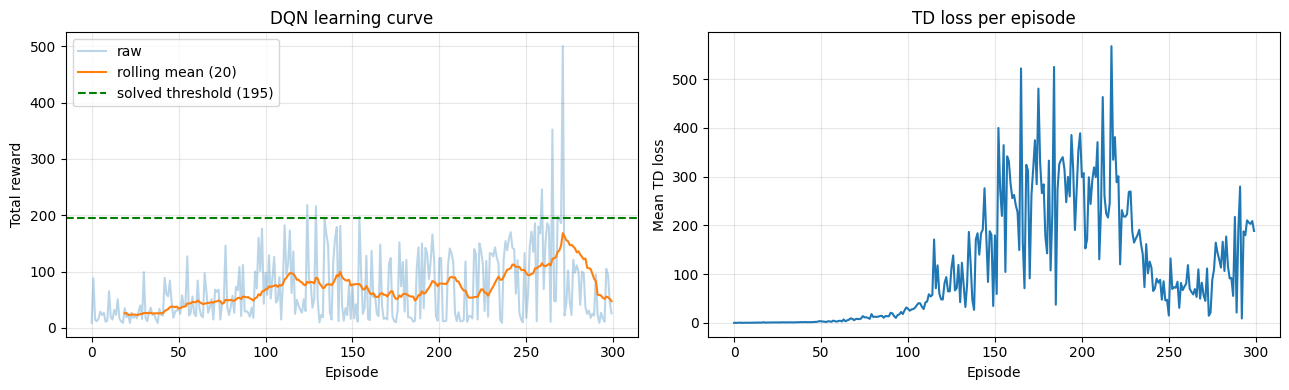

In [ ]:
# Two side-by-side plots: reward and loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-episode reward (raw + smoothed)
ax1.plot(rewards_log, alpha=0.3, label="raw")            # noisy per-episode reward
# Rolling mean to smooth the curve
window = 20                                              # smoothing window
if len(rewards_log) >= window:                           # safety check
    rolling = np.convolve(rewards_log, np.ones(window)/window, mode="valid")
    ax1.plot(range(window-1, len(rewards_log)), rolling, label=f"rolling mean ({window})")
ax1.axhline(195, color="green", linestyle="--", label="solved threshold (195)")
ax1.set_xlabel("Episode"); ax1.set_ylabel("Total reward")
ax1.set_title("DQN learning curve")
ax1.legend(); ax1.grid(alpha=0.3)

# Right: TD loss
ax2.plot(losses_log)
ax2.set_xlabel("Episode"); ax2.set_ylabel("Mean TD loss")
ax2.set_title("TD loss per episode")
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


What you should see:

Reward climbs from ~20 (random) toward 500 (max) over ~200 episodes.
The loss curve is noisier than supervised learning's — that's normal in RL, because the target itself changes as the network learns.

8. Evaluate the Trained Agent (Greedy)
At inference time we drop exploration entirely — pure greedy action selection.

In [ ]:
# Evaluation policy: greedy w.r.t. the learned Q-network
def greedy_policy(state):
    """Return argmax_a Q(s, a) — no exploration."""
    with torch.no_grad():                                  # no grad needed
        state_t = torch.FloatTensor(state).unsqueeze(0)    # batch of 1
        q = agent.online(state_t)                          # Q-values
        return int(q.argmax(dim=1).item())                 # best action

# Evaluate over 20 fresh episodes
eval_env = gym.make("CartPole-v1")                         # fresh env to avoid leftover state
trained_rewards = run_episodes(eval_env, greedy_policy, n_episodes=20)

# Compare against the random baseline
print(f"Random  policy mean reward: {np.mean(random_rewards):>6.1f}")
print(f"Trained policy mean reward: {np.mean(trained_rewards):>6.1f}")
print(f"\nImprovement: {np.mean(trained_rewards) / max(np.mean(random_rewards),1):.1f}× over random")

Random  policy mean reward:   21.1
Trained policy mean reward:  108.1

Improvement: 5.1× over random


9. Inspect What the Network Learned
A trained Q-network should give higher Q-value to the action that physically makes sense — e.g. when the pole is falling to the right, push the cart right.

In [ ]:
# Hand-craft a few states to probe the agent's behavior
# state = [cart_pos, cart_vel, pole_angle, pole_ang_vel]
test_states = {
    "Pole upright, no motion":    np.array([0.0,  0.0,  0.0,   0.0], dtype=np.float32),
    "Pole tilting right":         np.array([0.0,  0.0,  0.15,  0.5], dtype=np.float32),
    "Pole tilting left":          np.array([0.0,  0.0, -0.15, -0.5], dtype=np.float32),
}

# Query the trained Q-network on each
with torch.no_grad():                                      # inference only
    for name, s in test_states.items():                    # each scenario
        q = agent.online(torch.FloatTensor(s).unsqueeze(0)).squeeze().numpy()
        best = "RIGHT" if q[1] > q[0] else "LEFT"          # decode action
        print(f"{name:30} → Q(left)={q[0]:+.2f}, Q(right)={q[1]:+.2f}  →  push {best}")


Pole upright, no motion        → Q(left)=+204.34, Q(right)=+207.54  →  push RIGHT
Pole tilting right             → Q(left)=+126.98, Q(right)=+149.33  →  push RIGHT
Pole tilting left              → Q(left)=+290.21, Q(right)=+271.76  →  push LEFT
